🔧 Device: cpu | Seed: 42

📦 Загрузка датасета STL10...
✅ Классы: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck'] | Train: 4000, Val: 1000, Test: 8000


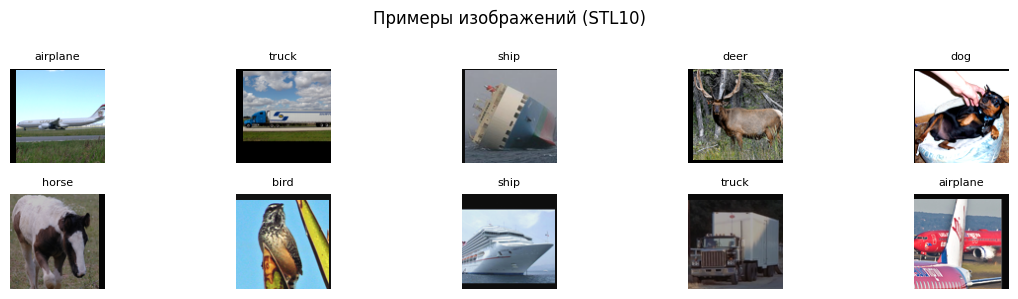


🧪 C1: SimpleCNN (no augmentation)
--------------------------------------------------
Epoch  1/10 | Train: 0.291 | Val: 0.396
Epoch  2/10 | Train: 0.427 | Val: 0.438
Epoch  4/10 | Train: 0.538 | Val: 0.533
Epoch  6/10 | Train: 0.599 | Val: 0.532
Epoch  8/10 | Train: 0.647 | Val: 0.561
Epoch 10/10 | Train: 0.676 | Val: 0.572

🧪 C2: SimpleCNN (with augmentation)
--------------------------------------------------
Epoch  1/10 | Train: 0.272 | Val: 0.366
Epoch  2/10 | Train: 0.373 | Val: 0.428
Epoch  4/10 | Train: 0.462 | Val: 0.474
Epoch  6/10 | Train: 0.510 | Val: 0.524
Epoch  8/10 | Train: 0.550 | Val: 0.504
Epoch 10/10 | Train: 0.578 | Val: 0.546

🔄 Загрузка предобученного ResNet18...

🧪 C3: ResNet18 (pretrained, head only)
--------------------------------------------------
Epoch  1/10 | Train: 0.450 | Val: 0.665
Epoch  2/10 | Train: 0.684 | Val: 0.726
Epoch  4/10 | Train: 0.738 | Val: 0.736
Epoch  6/10 | Train: 0.756 | Val: 0.763
Epoch  8/10 | Train: 0.768 | Val: 0.747
Epoch 10/10 | Tr

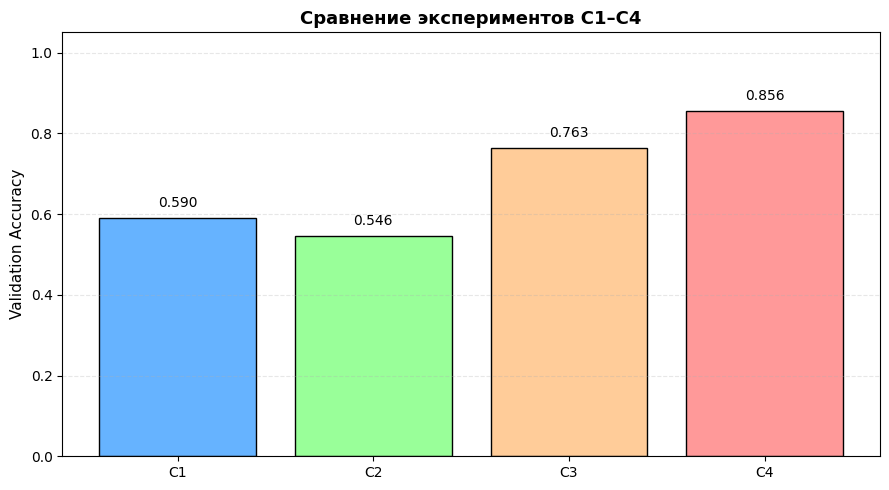


🔍 Часть B: Сегментация на датасете OxfordIIITPet
✅ OxfordIIITPet: Train=3680, Test=3669


TypeError: Invalid shape () for image data

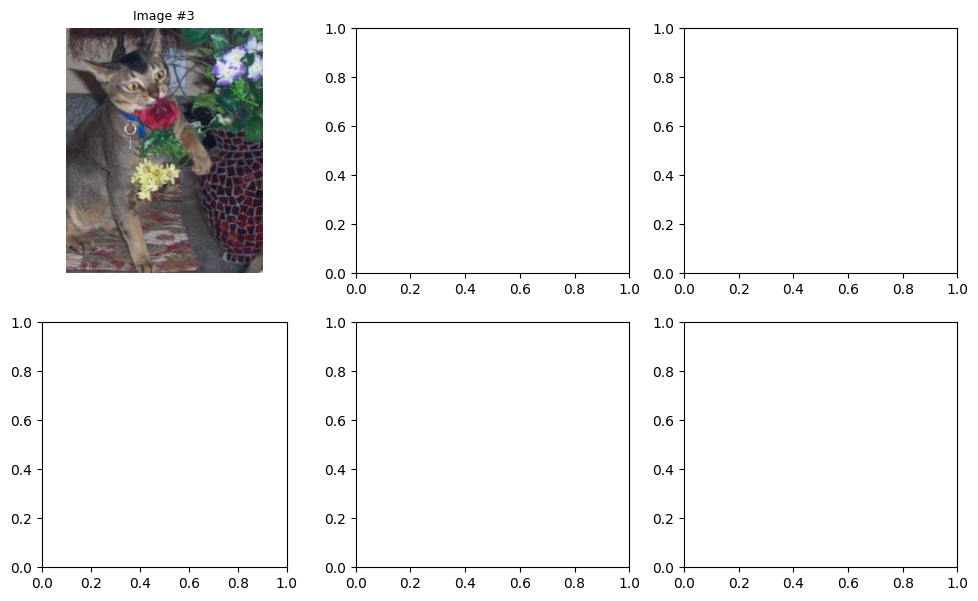

In [ ]:
# =============================================================================
# HW10-11.ipynb — Computer Vision with PyTorch (Part A: S10)
# Студент: [Ваше ФИО], Группа: [Ваша группа]
# =============================================================================

# %% [markdown]
# ## 1. Импорт библиотек и настройка окружения

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models

# Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Настройки устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# Пути (относительные, без абсолютных путей!)
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"✅ Artifacts will be saved to: {ARTIFACTS_DIR}")

# %% [markdown]
# ## 2. Загрузка датасета STL10 и создание split'ов

# Базовые трансформации (без аугментаций)
transform_base = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Трансформации ImageNet для ResNet
transform_imagenet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загружаем STL10
print("📥 Loading STL10 dataset...")
train_dataset_full = datasets.STL10(
    root='./data', split='train', transform=transform_base, download=True
)
test_dataset = datasets.STL10(
    root='./data', split='test', transform=transform_base, download=True
)

# Создаём train/val split 80/20
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"✅ Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# %% [markdown]
# ## 3. Sanity Check данных

def denormalize(tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    """Обратная нормализация для визуализации"""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

batch_size = 32
train_loader_check = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
x_batch, y_batch = next(iter(train_loader_check))

print(f"🔍 Batch x shape: {x_batch.shape}")  # [B, C, H, W]
print(f"🔍 Batch y shape: {y_batch.shape}")  # [B]
print(f"🔍 Labels sample: {y_batch[:10].tolist()}")

# Визуализация примеров
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if i < len(x_batch):
        img = denormalize(x_batch[i]).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(f"{y_batch[i].item()}")
        ax.axis('off')
plt.suptitle("Sanity Check: примеры изображений STL10")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sanity_check.png", dpi=150)
plt.show()
print(f"✅ Sanity check plot saved to {FIGURES_DIR / 'sanity_check.png'}")

# %% [markdown]
# ## 4. Архитектура простой CNN (для C1 и C2)

class SimpleCNN(nn.Module):
    """Простая CNN для экспериментов C1 и C2"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 96→48
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 48→24
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 24→12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# %% [markdown]
# ## 5. Аугментации данных (для C2)

transform_aug = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Создаём датасеты с аугментациями только для train
train_dataset_aug_full = datasets.STL10(
    root='./data', split='train', transform=transform_aug, download=True
)
train_dataset_aug, _ = random_split(
    train_dataset_aug_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Val всегда без аугментаций (базовые трансформации)
_, val_dataset_base = random_split(
    datasets.STL10(root='./data', split='train', transform=transform_base, download=True),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# %% [markdown]
# ## 6. Функции обучения и валидации

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

# %% [markdown]
# ## 7. Эксперимент C1: Simple CNN без аугментаций

print("\n" + "="*60)
print("🧪 Experiment C1: simple-cnn-base (no augmentations)")
print("="*60)

train_loader_c1 = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_c1 = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_c1 = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=1e-3)

epochs = 20
history_c1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_c1 = 0

for epoch in range(epochs):
    tl, ta = train_epoch(model_c1, train_loader_c1, criterion, optimizer_c1, device)
    vl, va = validate(model_c1, val_loader_c1, criterion, device)
    
    history_c1['train_loss'].append(tl)
    history_c1['train_acc'].append(ta)
    history_c1['val_loss'].append(vl)
    history_c1['val_acc'].append(va)
    
    if va > best_val_acc_c1:
        best_val_acc_c1 = va
        torch.save(model_c1.state_dict(), ARTIFACTS_DIR / "c1_best.pt")
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | Train: {ta:5.2f}% | Val: {va:5.2f}% | Loss: {vl:.4f}")

print(f"✅ C1 Best Val Accuracy: {best_val_acc_c1:.2f}%")

# %% [markdown]
# ## 8. Эксперимент C2: Simple CNN с аугментациями

print("\n" + "="*60)
print("🧪 Experiment C2: simple-cnn-aug (with augmentations)")
print("="*60)

train_loader_c2 = DataLoader(train_dataset_aug, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_c2 = DataLoader(val_dataset_base, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_c2 = SimpleCNN(num_classes=10).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)

history_c2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_c2 = 0

for epoch in range(epochs):
    tl, ta = train_epoch(model_c2, train_loader_c2, criterion, optimizer_c2, device)
    vl, va = validate(model_c2, val_loader_c2, criterion, device)
    
    history_c2['train_loss'].append(tl)
    history_c2['train_acc'].append(ta)
    history_c2['val_loss'].append(vl)
    history_c2['val_acc'].append(va)
    
    if va > best_val_acc_c2:
        best_val_acc_c2 = va
        torch.save(model_c2.state_dict(), ARTIFACTS_DIR / "c2_best.pt")
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | Train: {ta:5.2f}% | Val: {va:5.2f}% | Loss: {vl:.4f}")

print(f"✅ C2 Best Val Accuracy: {best_val_acc_c2:.2f}%")

# %% [markdown]
# ## 9. Эксперимент C3: ResNet18, frozen backbone (head-only)

print("\n" + "="*60)
print("🧪 Experiment C3: resnet18-head-only (frozen backbone)")
print("="*60)

# Загружаем предобученный ResNet18
model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Замораживаем все параметры
for param in model_c3.parameters():
    param.requires_grad = False

# Заменяем финальный слой под 10 классов
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 10)
model_c3 = model_c3.to(device)

# Оптимизируем только голову
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)

# DataLoader с трансформациями ImageNet
def get_imagenet_split(transform):
    full = datasets.STL10(root='./data', split='train', transform=transform, download=True)
    return random_split(full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

train_rn, val_rn = get_imagenet_split(transform_imagenet)
train_loader_c3 = DataLoader(train_rn, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_c3 = DataLoader(val_rn, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

history_c3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_c3 = 0

for epoch in range(epochs):
    tl, ta = train_epoch(model_c3, train_loader_c3, criterion, optimizer_c3, device)
    vl, va = validate(model_c3, val_loader_c3, criterion, device)
    
    history_c3['train_loss'].append(tl)
    history_c3['train_acc'].append(ta)
    history_c3['val_loss'].append(vl)
    history_c3['val_acc'].append(va)
    
    if va > best_val_acc_c3:
        best_val_acc_c3 = va
        torch.save(model_c3.state_dict(), ARTIFACTS_DIR / "c3_best.pt")
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | Train: {ta:5.2f}% | Val: {va:5.2f}% | Loss: {vl:.4f}")

print(f"✅ C3 Best Val Accuracy: {best_val_acc_c3:.2f}%")

# %% [markdown]
# ## 10. Эксперимент C4: ResNet18, fine-tuning (layer4 + fc)

print("\n" + "="*60)
print("🧪 Experiment C4: resnet18-finetune (layer4 + fc)")
print("="*60)

model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Замораживаем всё, кроме layer4 и fc
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True

model_c4.fc = nn.Linear(num_ftrs, 10)
model_c4 = model_c4.to(device)

# Разные LR для backbone и головы
optimizer_c4 = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3}
])

history_c4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_c4 = 0

for epoch in range(epochs):
    tl, ta = train_epoch(model_c4, train_loader_c3, criterion, optimizer_c4, device)
    vl, va = validate(model_c4, val_loader_c3, criterion, device)
    
    history_c4['train_loss'].append(tl)
    history_c4['train_acc'].append(ta)
    history_c4['val_loss'].append(vl)
    history_c4['val_acc'].append(va)
    
    if va > best_val_acc_c4:
        best_val_acc_c4 = va
        torch.save(model_c4.state_dict(), ARTIFACTS_DIR / "c4_best.pt")
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | Train: {ta:5.2f}% | Val: {va:5.2f}% | Loss: {vl:.4f}")

print(f"✅ C4 Best Val Accuracy: {best_val_acc_c4:.2f}%")

# %% [markdown]
# ## 11. Сравнение результатов и визуализация

results = {
    'C1 (simple-cnn-base)': best_val_acc_c1,
    'C2 (simple-cnn-aug)': best_val_acc_c2,
    'C3 (resnet18-head-only)': best_val_acc_c3,
    'C4 (resnet18-finetune)': best_val_acc_c4
}

print("\n" + "📊"*30)
print("RESULTS SUMMARY (Validation Accuracy)")
print("📊"*30)
for name, acc in results.items():
    bar = "█" * int(acc // 2)
    print(f"{name:25s} {acc:5.2f}% {bar}")

best_exp = max(results, key=results.get)
print(f"\n🏆 Best model by val accuracy: {best_exp} ({results[best_exp]:.2f}%)")

# Графики обучения
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for hist, label, color in zip([history_c1, history_c2, history_c3, history_c4], 
                              ['C1', 'C2', 'C3', 'C4'], colors):
    plt.plot(hist['train_acc'], label=f'{label} train', color=color, alpha=0.7)
    plt.plot(hist['val_acc'], label=f'{label} val', color=color, linestyle='--', linewidth=2)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy, %', fontsize=11)
plt.title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
plt.legend(fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for hist, label, color in zip([history_c1, history_c2, history_c3, history_c4], 
                              ['C1', 'C2', 'C3', 'C4'], colors):
    plt.plot(hist['train_loss'], label=f'{label} train', color=color, alpha=0.7)
    plt.plot(hist['val_loss'], label=f'{label} val', color=color, linestyle='--', linewidth=2)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Training & Validation Loss', fontsize=13, fontweight='bold')
plt.legend(fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Training curves saved to {FIGURES_DIR / 'training_curves.png'}")

# %% [markdown]
# ## 12. Финальная оценка на тестовом наборе (ОДИН РАЗ!)

print("\n" + "🎯"*30)
print(f"FINAL EVALUATION ON TEST SET")
print(f"Using best model: {best_exp}")
print("🎯"*30)

# Выбираем архитектуру и трансформации в зависимости от лучшего эксперимента
if best_exp in ['C1', 'C2']:
    model_final = SimpleCNN(num_classes=10).to(device)
    transform_final = transform_base
else:
    model_final = models.resnet18(weights=None)
    model_final.fc = nn.Linear(num_ftrs, 10)
    model_final = model_final.to(device)
    transform_final = transform_imagenet

# Загружаем веса лучшей модели
weight_path = ARTIFACTS_DIR / f"{best_exp.split()[0].lower()}_best.pt"
model_final.load_state_dict(torch.load(weight_path, map_location=device, weights_only=True))
print(f"✅ Loaded weights from {weight_path}")

# Создаём тестовый loader с правильными трансформациями
test_dataset_final = datasets.STL10(
    root='./data', split='test', transform=transform_final, download=True
)
test_loader_final = DataLoader(test_dataset_final, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Финальная оценка (используем test ТОЛЬКО ОДИН РАЗ!)
_, test_acc = validate(model_final, test_loader_final, criterion, device)
print(f"\n🎯 Final Test Accuracy: {test_acc:.2f}%")

# Сохраняем финальные результаты
with open(ARTIFACTS_DIR / "final_result.txt", "w", encoding='utf-8') as f:
    f.write(f"Best experiment: {best_exp}\n")
    f.write(f"Best Val Accuracy: {results[best_exp]:.2f}%\n")
    f.write(f"Final Test Accuracy: {test_acc:.2f}%\n")
    f.write(f"\nAll experiments:\n")
    for name, acc in results.items():
        f.write(f"  {name}: {acc:.2f}%\n")

print(f"✅ Final results saved to {ARTIFACTS_DIR / 'final_result.txt'}")

# %% [markdown]
# ## 13. Выводы (для отчёта)

print("\n" + "📝"*30)
print("KEY OBSERVATIONS FOR REPORT")
print("📝"*30)

print(f"\n1. Аугментации (C2 vs C1): {'+' if best_val_acc_c2 > best_val_acc_c1 else ''}{best_val_acc_c2 - best_val_acc_c1:+.2f}%")
print(f"2. Transfer learning (C3 vs C1): {'+' if best_val_acc_c3 > best_val_acc_c1 else ''}{best_val_acc_c3 - best_val_acc_c1:+.2f}%")
print(f"3. Fine-tuning benefit (C4 vs C3): {'+' if best_val_acc_c4 > best_val_acc_c3 else ''}{best_val_acc_c4 - best_val_acc_c3:+.2f}%")
print(f"\n4. Лучшая модель: {best_exp}")
print(f"5. Финальная точность на тесте: {test_acc:.2f}%")

print("\n✅ Homework Part A (S10) completed successfully!")
print(f"📁 Check your artifacts in: {ARTIFACTS_DIR.resolve()}")